# Route-3 7D Coverage Failure Diagnosis

This notebook independently audits the already-inspected Notebook-18 evidence.
It does not tune against a final test set and does not alter Notebooks 15--18.
The scientific target is posterior calibration in the synthetic cortical-rate
observable space, not real EEG inference.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "S4_sbi").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "S4_sbi").exists():
    raise RuntimeError("sleep_loop project root could not be resolved")
sys.path.insert(0, str(PROJECT_ROOT / "S4_sbi" / "src"))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "route3_7d_rescue"
print("CONDA_DEFAULT_ENV=", os.environ.get("CONDA_DEFAULT_ENV"))
print("sys.executable=", sys.executable)
print("sys.prefix=", sys.prefix)
print("PROJECT_ROOT=", PROJECT_ROOT)
assert "neurolib" in sys.executable.lower()


CONDA_DEFAULT_ENV= neurolib
sys.executable= C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
sys.prefix= C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib
PROJECT_ROOT= D:\Year3_Mao_Projects\sleep_loop


## Frozen evidence and independent recomputation


In [2]:
from sleep_sbi.route3_7d_rescue import diagnose_original_failure
diagnosis = diagnose_original_failure()
display(pd.DataFrame([diagnosis["summary"]]).T.rename(columns={0: "value"}))
assert diagnosis["summary"]["verified_implementation_bug_found"] is False
assert diagnosis["summary"]["posterior_mc_halves_stable"] is True


,value
created_utc,2026-07-28T04:12:11.138117+00:00
original_preregistration_hash,2cedb6a68de307ab2f9233b4009a8f58854316259b6c18...
original_criteria_hash,49a4f9590466a6d9ba83f83ee5b6783e268ba996f8e8fc...
posterior_artifact_hash,368d2c7292a13a0fb0fd9b5bfba746572a925576306243...
posterior_shape,"[256, 4096, 7]"
posterior_finite,True
posterior_in_unit_prior,True
x_scaled_finite,True
train_validation_disjoint,True
scaler_recomputed_from_training_only_match,True


## Per-network and ensemble coverage

Each curve uses central credible intervals. Similar undercoverage in the three
members and the equal mixture argues against accidental pooling or narrowing.


In [3]:
coverage = diagnosis["coverage"]
display(coverage[coverage.nominal_level.isin([0.5, 0.8, 0.9])].round(4))


,estimator,parameter,nominal_level,covered,n,empirical_coverage,wilson_95_low,wilson_95_high,nominal_inside_wilson,severe_undercoverage
4,ensemble,mue,0.5,101,256,0.3945,0.3366,0.4555,False,False
7,ensemble,mue,0.8,172,256,0.6719,0.6122,0.7265,False,False
8,ensemble,mue,0.9,208,256,0.8125,0.7602,0.8556,False,False
13,ensemble,mui,0.5,165,256,0.6445,0.5842,0.7006,False,False
16,ensemble,mui,0.8,231,256,0.9023,0.8598,0.9330,False,False
...,...,...,...,...,...,...,...,...,...,...
241,member_2,g_h,0.8,187,256,0.7305,0.6730,0.7811,False,False
242,member_2,g_h,0.9,216,256,0.8438,0.7942,0.8831,False,False
247,member_2,c_th2ctx,0.5,95,256,0.3711,0.3142,0.4318,False,False
250,member_2,c_th2ctx,0.8,175,256,0.6836,0.6243,0.7375,False,False


## Bias, posterior width, and prior boundaries

Coverage near a bounded prior can fail even when point bias averaged over the
whole prior is small. The red/blue contrast is diagnostic, not a license to
remove boundary cases.


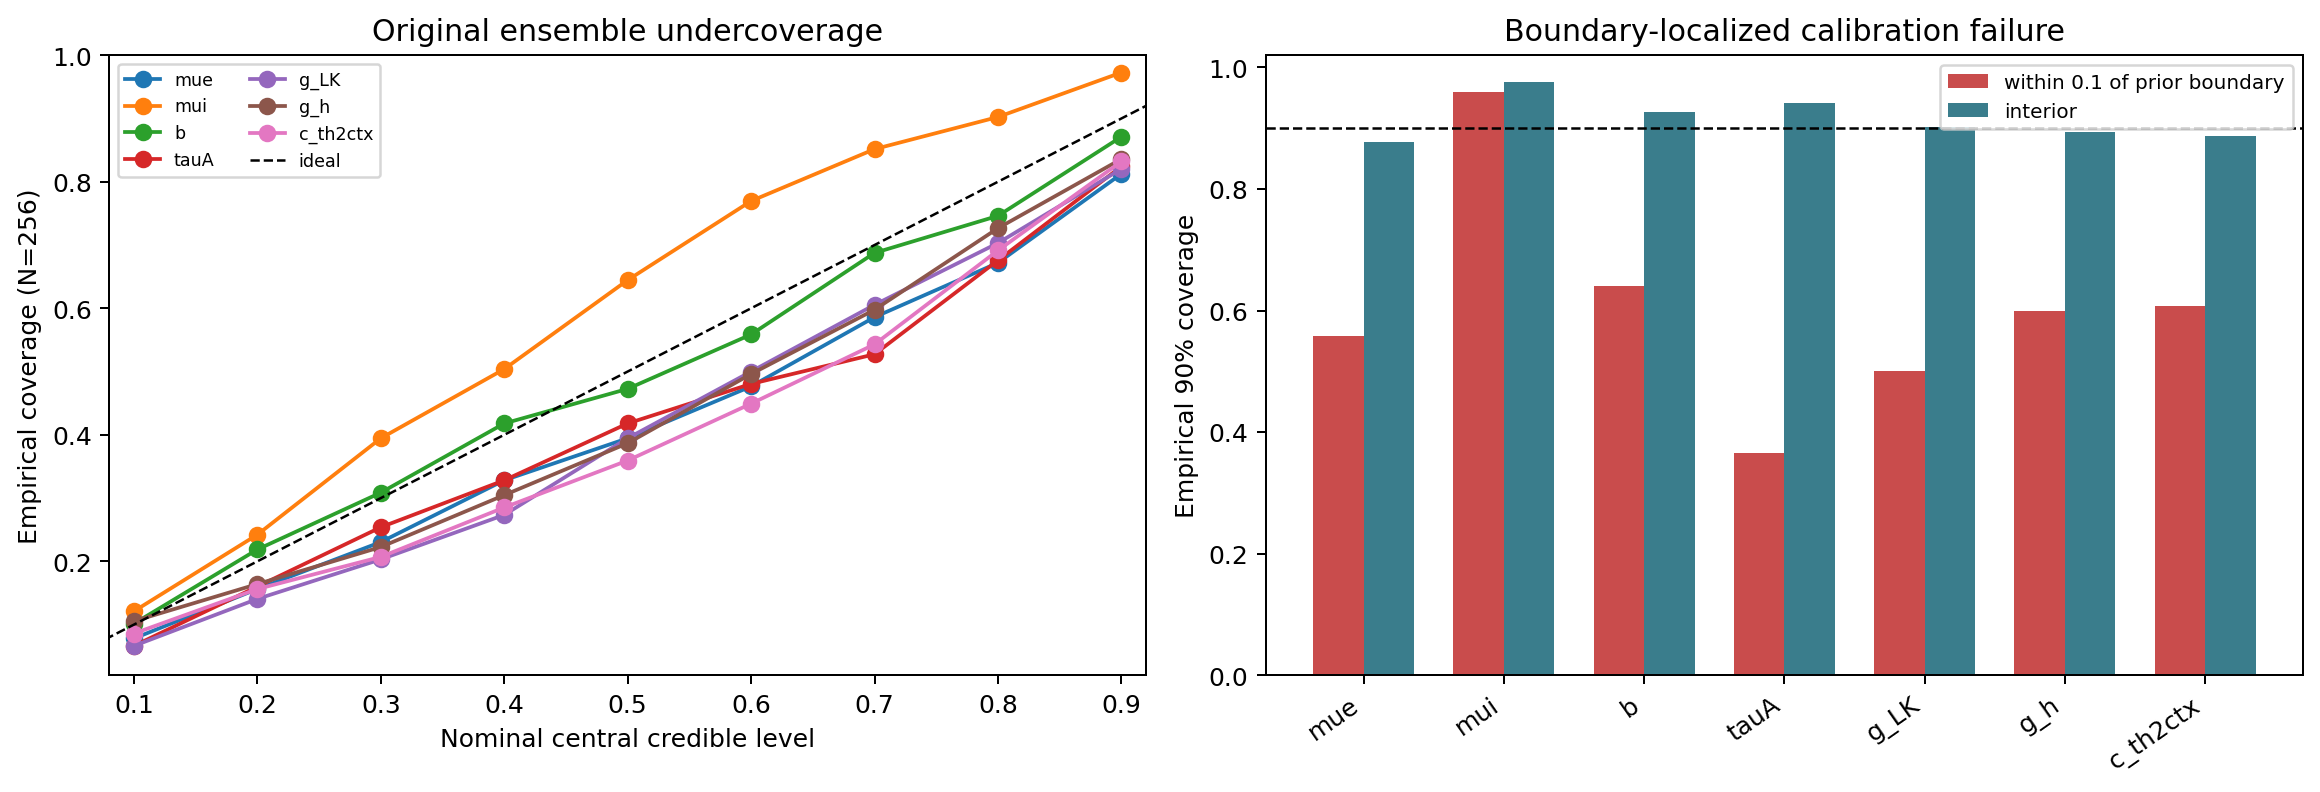

,parameter,mean_bias,mean_abs_error,median_width_90,boundary_case_count,coverage_90_boundary,coverage_90_interior,rank_mean
0,mue,-0.0112,0.1467,0.5062,52,0.5577,0.8775,0.5233
1,mui,0.0013,0.0049,0.0167,50,0.9600,0.9757,0.4226
2,b,-0.0138,0.0879,0.3116,50,0.6400,0.9272,0.5333
3,tauA,0.0023,0.1863,0.6601,52,0.3654,0.9412,0.5070
4,g_LK,0.0132,0.1512,0.4986,52,0.5000,0.9020,0.5056
5,g_h,0.0232,0.1256,0.4155,50,0.6000,0.8932,0.4819
6,c_th2ctx,-0.0284,0.1453,0.5035,51,0.6078,0.8878,0.4824


In [4]:
from sleep_sbi.route3_7d_rescue_reporting import plot_diagnosis
png, svg = plot_diagnosis()
display(Image(filename=str(png)))
display(diagnosis["decomposition"].round(4))


## Diagnosis

No verified transform, scaler, mixture-count, posterior-pooling, interval, NaN,
or Monte Carlo bug explains the result. The rescue therefore remains a genuine
training/calibration experiment. The old 256 cases are development evidence only.
